<a href="https://colab.research.google.com/github/rohinikshirasagar123-crypto/Heart-Disease-Data-Analysis/blob/main/Dataset_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Q1. Load Dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

print("First 10 Rows:")
print(df.head(10))

print("\nShape:")
print(df.shape)

print("\nInfo:")
df.info()

First 10 Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

In [ ]:
# Q2. Missing Values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Q3. Duplicate Rows

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (918, 12)


In [ ]:
# Q4. Invalid Values

chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Cholesterol = 0 :", chol_zero)
print("RestingBP = 0 :", bp_zero)

Cholesterol = 0 : 172
RestingBP = 0 : 1


In [ ]:
# Q5. Cleaning Invalid Values

print("Before Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()

df.loc[df["Cholesterol"] == 0, "Cholesterol"] = round(chol_mean,2)
df.loc[df["RestingBP"] == 0, "RestingBP"] = round(bp_mean,2)

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

Before Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


/tmp/ipykernel_2485/3938294103.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '244.64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["Cholesterol"] == 0, "Cholesterol"] = round(chol_mean,2)
/tmp/ipykernel_2485/3938294103.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.54' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["RestingBP"] == 0, "RestingBP"] = round(bp_mean,2)


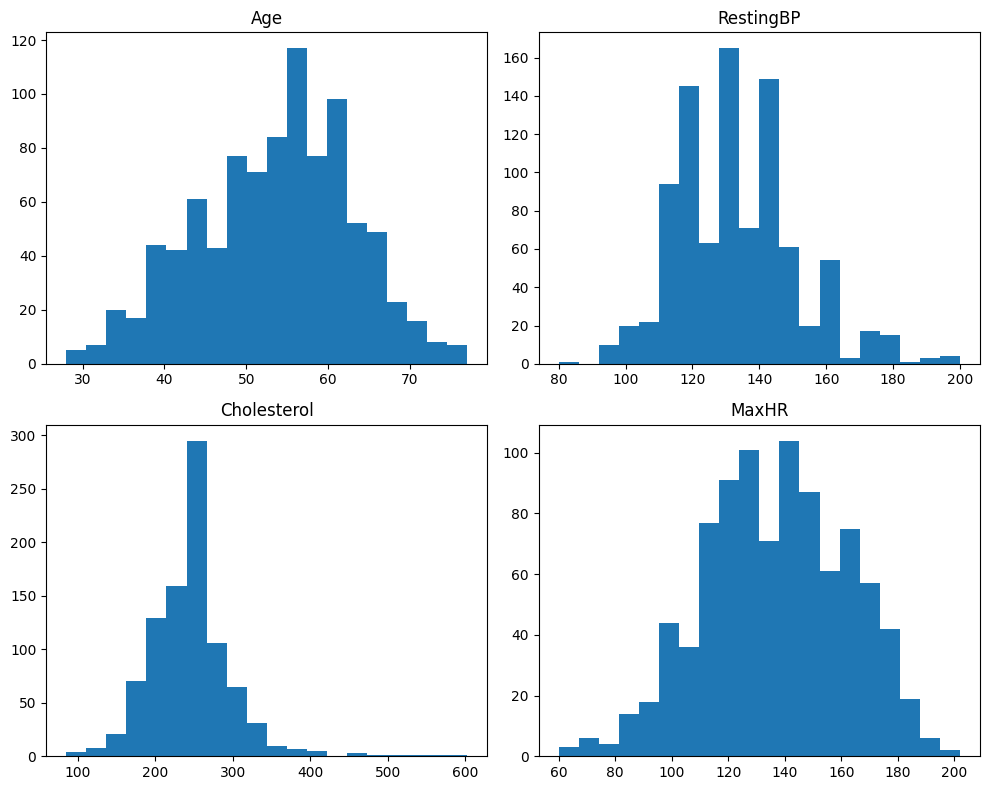

In [ ]:
# Q6. Histograms

import matplotlib.pyplot as plt

def plot_hist(column):
    plt.hist(df[column], bins=20)

    plt.title(column)

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plot_hist("Age")

plt.subplot(2,2,2)
plot_hist("RestingBP")

plt.subplot(2,2,3)
plot_hist("Cholesterol")
plt.subplot(2,2,4)
plot_hist("MaxHR")

plt.tight_layout()
plt.show()

In [ ]:
# Q7. Numerical and Categorical Columns

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [ ]:
# Q8. One-Hot Encoding

df_encoded = pd.get_dummies(df)

print("Shape:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
print(df_encoded.head())

Shape:
(918, 21)

First 5 Rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal

In [ ]:
# Q9. Final Shape and Columns

print("Final Shape:")
print(df_encoded.shape)

print("\nColumn Names:")
print(df_encoded.columns.tolist())

Final Shape:
(918, 21)

Column Names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
